# Optimización y Validación de los Estadios de Inclusión Digital
**CC3074 - Minería de Datos | Proyecto Final**

## Justificación de la Investigación
El análisis tradicional de la brecha digital en las ciencias sociales suele limitarse a clasificaciones estáticas que no capturan la realidad del cambio tecnológico. Esta investigación propone un cambio de paradigma hacia una visión procesual. Se busca entender la inclusión como un recorrido evolutivo dinámico en lugar de una característica fija de cada nación. 

El uso de observaciones que combinan país y año permite que el algoritmo descubra los Arquetipos de Inclusión. Estos arquetipos representan los estadios de desarrollo que atraviesan las sociedades latinoamericanas. La metodología no solo identifica la posición actual de cada país sino también su capacidad de avance hacia niveles superiores de madurez digital.

## Configuración 
La estandarización global es la decisión técnica más relevante del proceso inicial. Al normalizar todos los años y países en un único conjunto de referencia, aseguramos que la medición sea consistente a través del tiempo. Esto permite que el Estadio 2 represente exactamente el mismo nivel de madurez tecnológica sin importar el año de la observación. 

Si se aplicara un escalamiento relativo por año, el progreso real quedaría oculto. La variabilidad del valor máximo de conectividad en cada periodo cambiaría la regla de medición constantemente. Este enfoque global transforma el modelo en una unidad de medida fija que permite observar el crecimiento histórico de forma objetiva.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, make_scorer

CONFIG = {
    'SEED': 42,
    'DATA_PATH': 'data_per_age_group.csv',
    'FEATURES': {
        'edad de medicion a 17 años': 'u17',
        '18 a 25 años de edad': '18_25',
        '26 a 50 años de edad': '26_50',
        '51 a 65 años': '51_65',
        '66 años en adelante': 'o66'
    },
    'COUNTRY_CLEANUP': {
        'Bolivia (Estado Plurinacional de)': 'Bolivia'
    }
}

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

def load_and_preprocess():
    df = pd.read_csv(CONFIG['DATA_PATH'])
    df = df.rename(columns=CONFIG['FEATURES'])
    FEATURE_COLS = list(CONFIG['FEATURES'].values())
    df['country_short'] = df['country'].replace(CONFIG['COUNTRY_CLEANUP'])
    df = df.dropna(subset=FEATURE_COLS).copy()
    X_scaled = StandardScaler().fit_transform(df[FEATURE_COLS])
    return df, X_scaled, FEATURE_COLS

df, X_scaled, FEATURE_COLS = load_and_preprocess()
print(f"Datos cargados. Observaciones País-Año: {df.shape[0]}")

Datos cargados. Observaciones País-Año: 145


## 2. El Filtro Semántico 

Un modelo estadísticamente impecable puede carecer de utilidad práctica si sus resultados contradicen los principios fundamentales del desarrollo social. Por ejemplo, un grupo de datos que muestre una alta digitalización en adultos mayores pero una nula conexión en jóvenes no tiene sentido lógico en la realidad actual. Un modelo de este tipo sería un artefacto matemático sin valor para la toma de decisiones.

Para evitar este problema, se implementan Restricciones de Coherencia que actúan como un puente entre los datos y la teoría social:
1. **Jerarquía Lógica o Monotonicidad:** Los estadios identificados deben seguir una secuencia de crecimiento clara. Cada etapa superior debe presentar niveles de inclusión mayores que la anterior.
2. **Identidad de Etapa o Diferenciación:** Los grupos deben ser lo suficientemente distintos entre sí para representar etapas de vida social únicas. Esto previene la creación de categorías repetitivas que no aportan información nueva.
3. **Importancia Estadística o Representatividad:** Se eliminan los grupos que contienen muy pocos datos. Esto asegura que los resultados sean representativos de la población y tengan peso suficiente para influir en las políticas públicas.

Este proceso de filtrado permite que el aprendizaje automático deje de ser una caja negra y se convierta en una herramienta alineada con la realidad histórica y social.

In [2]:
def check_social_constraints(labels, X):
    """Verifica si el clustering cumple con reglas sociales básicas."""
    temp_df = pd.DataFrame(X, columns=FEATURE_COLS)
    temp_df['cluster'] = labels
    perfiles = temp_df.groupby('cluster').mean()
    
    # 1. Monotonicidad
    orden_clusters = perfiles.mean(axis=1).sort_values().index
    perfiles_ordenados = perfiles.loc[orden_clusters]
    
    # 2. Diferenciación
    if (perfiles_ordenados.diff().dropna() < 0.1).all(axis=1).any():
        return False
        
    # 3. Representatividad
    if (pd.Series(labels).value_counts(normalize=True) < 0.05).any():
        return False
        
    return True

def validez_sociologica_score(estimator, X):
    """Score híbrido: Silhouette si es socialmente válido, -1 si no."""
    try:
        labels = estimator.fit_predict(X)
        if not check_social_constraints(labels, X):
            return -1.0
        return silhouette_score(X, labels)
    except:
        return -1.0

print("Lógica de validación refactorizada ✓")

Lógica de validación refactorizada ✓


## 3. HyperParameter Tuning

El uso de un solo algoritmo puede introducir sesgos geométricos en los resultados. Modelos como KMeans tienden a favorecer la creación de grupos con formas esféricas. Para confirmar que los estadios de inclusión son estructuras reales de las sociedades y no un error del método, se comparan dos naturalezas algorítmicas diferentes:
*   **KMeans con Fronteras Rígidas:** Este método es ideal para capturar estados de equilibrio claros y bien definidos entre los datos.
*   **Clustering Jerárquico Aglomerativo:** Este enfoque permite observar la genealogía del desarrollo. Es útil para entender cómo los países se distancian progresivamente del bloque rezagado.

El rango de búsqueda para el número de grupos se establece entre tres y cinco. Esta elección busca capturar con precisión el estadio de transición. Identificar esta etapa es fundamental para entender los puntos donde la brecha digital generacional es más profunda y requiere atención urgente.

In [3]:
def perform_tuning(X):
    results = []
    for k in range(3, 6):
        for init in ['k-means++', 'random']:
            model = KMeans(n_clusters=k, init=init, n_init=20, random_state=CONFIG['SEED'])
            score = validez_sociologica_score(model, X)
            results.append({'algoritmo': 'KMeans', 'k': k, 'params': f"init={init}", 'social_score': score})
            
    for k in range(3, 6):
        for linkage in ['ward', 'complete', 'average']:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            score = validez_sociologica_score(model, X)
            results.append({'algoritmo': 'Agglomerative', 'k': k, 'params': f"linkage={linkage}", 'social_score': score})
    return pd.DataFrame(results)

tuning_results = perform_tuning(X_scaled)
valid_models = tuning_results[tuning_results['social_score'] > 0].sort_values(by='social_score', ascending=False)

print("\nTop 5 Modelos Socialmente Válidos:")
print(valid_models.head(5))

best_row = valid_models.iloc[0]
print(f"\nGanador: {best_row['algoritmo']} (k={best_row['k']}, {best_row['params']})")


Top 5 Modelos Socialmente Válidos:
       algoritmo  k           params  social_score
0         KMeans  3   init=k-means++      0.462852
1         KMeans  3      init=random      0.462852
6  Agglomerative  3     linkage=ward      0.438524
8  Agglomerative  3  linkage=average      0.433808
2         KMeans  4   init=k-means++      0.433703

Ganador: KMeans (k=3, init=k-means++)


## 4. Ajuste Final del Modelo Ganador
Aplicación del modelo que equilibra la estabilidad estadística con la coherencia social.

In [4]:
if best_row['algoritmo'] == 'KMeans':
    init = best_row['params'].split('=')[1]
    best_model = KMeans(n_clusters=best_row['k'], init=init, n_init=50, random_state=CONFIG['SEED'])
else:
    linkage = best_row['params'].split('=')[1]
    best_model = AgglomerativeClustering(n_clusters=best_row['k'], linkage=linkage)

df['estadio_final'] = best_model.fit_predict(X_scaled)

## 5. Visualización
Los valores numéricos generados por los algoritmos son abstractos y difíciles de comunicar a un público no técnico. En el diseño de políticas públicas, es vital traducir estos hallazgos a un lenguaje comprensible. Etiquetas como Rezago o Madurez Digital transforman un dato estadístico en una herramienta de gobernanza clara. Esto facilita la creación de estrategias dirigidas a cerrar brechas específicas.

Los gráficos presentados cumplen funciones estratégicas distintas:
1.  **Gráfica de Radar para Perfiles Generacionales:** Este diagrama permite visualizar cómo se distribuye la inclusión entre las distintas edades. Un estadio se considera avanzado cuando muestra una huella equilibrada. Esto significa que tanto jóvenes como adultos mayores participan activamente del entorno digital.
2.  **Evolución del Bloque Regional:** Analizar el progreso de Latinoamérica como conjunto es fundamental para detectar tendencias generales. Ayuda a determinar si la región avanza hacia una madurez compartida o si algunos países se han estancado en etapas de transición de forma permanente.

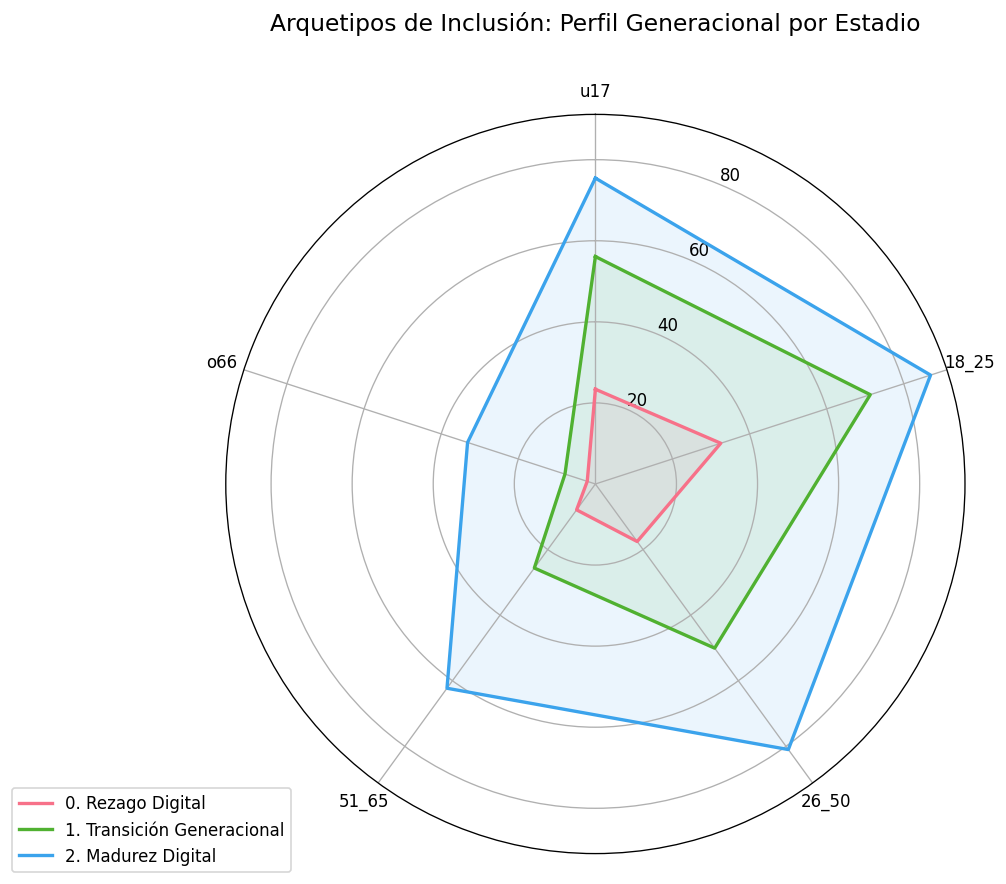

<Figure size 1440x720 with 0 Axes>

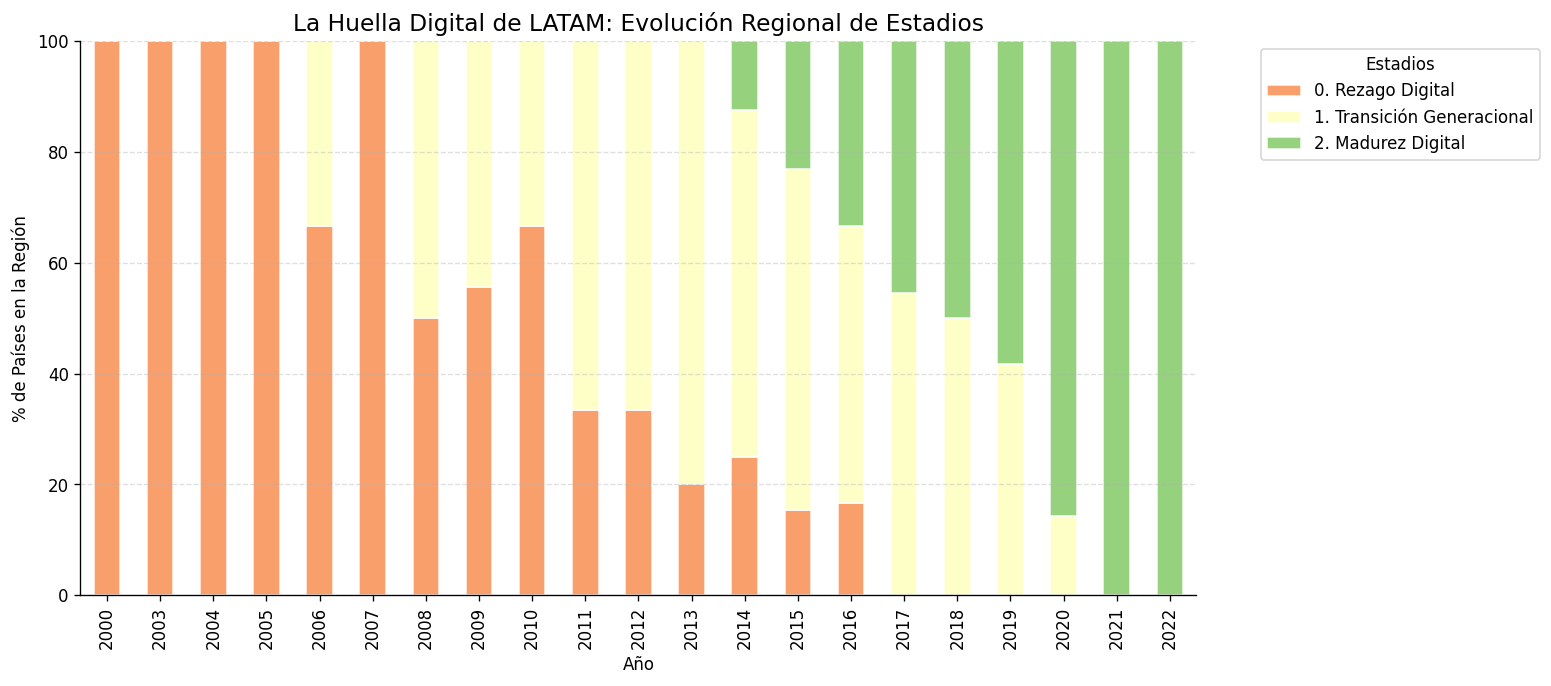

In [5]:
cluster_order = df.groupby('estadio_final')[FEATURE_COLS].mean().mean(axis=1).sort_values().index
map_ord = {old: new for new, old in enumerate(cluster_order)}
df['estadio_num'] = df['estadio_final'].map(map_ord)

NOMBRES_ESTADIOS = {
    0: "0. Rezago Digital",
    1: "1. Transición Generacional",
    2: "2. Madurez Digital",
    3: "3. Avanzado (Full-Adoption)",
    4: "4. Pionero Digital"
}
df['estadio'] = df['estadio_num'].map(NOMBRES_ESTADIOS)

from math import pi
def plot_radar(df_perfil):
    categories = list(df_perfil.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = sns.color_palette("husl", len(df_perfil))
    for i, (idx, row) in enumerate(df_perfil.iterrows()):
        values = row.values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=idx, color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], categories)
    plt.title('Arquetipos de Inclusión: Perfil Generacional por Estadio', y=1.1, fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.show()

perfil_real = df.groupby('estadio')[FEATURE_COLS].mean()
plot_radar(perfil_real)

plt.figure(figsize=(12, 6))
evolucion = df.groupby(['year', 'estadio']).size().unstack(fill_value=0)
evolucion_pct = evolucion.div(evolucion.sum(axis=1), axis=0) * 100
evolucion_pct.plot(kind='bar', stacked=True, figsize=(12, 6), 
                   color=sns.color_palette("RdYlGn", len(evolucion_pct.columns)),
                   alpha=0.85, edgecolor='white')
plt.title('La Huella Digital de LATAM: Evolución Regional de Estadios', fontsize=14)
plt.ylabel('% de Países en la Región'); plt.xlabel('Año')
plt.legend(title='Estadios', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4); plt.show()

## 6. Análisis Extendido

Un modelo destinado a la investigación social debe demostrar una alta robustez técnica. Si la estructura de los estadios cambia drásticamente al eliminar una pequeña fracción de los datos, el modelo no es confiable para orientar inversiones o políticas de largo plazo. La inestabilidad matemática se traduce en incertidumbre para las instituciones que dependen de estos hallazgos.

Para garantizar la validez de los resultados, se aplica una prueba de estabilidad mediante el método de Bootstrap y el índice ARI. Esta métrica asegura que las etapas de desarrollo identificadas son reales y permanecen constantes a pesar de pequeñas variaciones en la muestra. Los diagramas de caja complementan este análisis al mostrar la cohesión interna de cada grupo. Una baja varianza en los datos indica que el estadio de desarrollo está bien definido y representa fielmente la realidad del grupo social estudiado.

In [ ]:
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

def check_stability(X, model, n_iterations=10):
    scores = []
    base_labels = model.fit_predict(X)
    for i in range(n_iterations):
        X_resampled, indices = resample(X, range(len(X)), n_samples=int(0.9*len(X)), random_state=i)
        resampled_labels = model.fit_predict(X_resampled)
        ari = adjusted_rand_score(base_labels[indices], resampled_labels)
        scores.append(ari)
    return np.mean(scores)

stability_idx = check_stability(X_scaled, best_model)
print(f"\nÍndice de Estabilidad (Bootstrap ARI): {stability_idx:.4f}")

plt.figure(figsize=(12, 6))
df_melted = df.melt(id_vars=['estadio'], value_vars=FEATURE_COLS, var_name='Grupo Edad', value_name='Tasa Inclusión')
sns.boxplot(data=df_melted, x='Grupo Edad', y='Tasa Inclusión', hue='estadio', palette='RdPu')
plt.title('Dispersión y Coherencia: Variabilidad de la Inclusión por Estadio')
plt.grid(axis='y', alpha=0.3); plt.show()